# Zachary's Karate Club dataset experiments

In [1]:
!pip install -qr requirements.txt

DEPRECATION: Loading egg at /opt/homebrew/Cellar/tbb/2021.12.0/lib/python3.12/site-packages/TBB-0.2-py3.12-macosx-13.0-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.1.1 -> 24.2
[notice] To update, run: /opt/homebrew/opt/python@3.12/bin/python3.12 -m pip install --upgrade pip


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings
warnings.simplefilter("ignore")

In [4]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

# deep stuff
import torch
from torch_geometric.utils import from_networkx

In [5]:
from src.community_results import community_metrics, plot_communities, community_size_hist
from src.clustering import label_propagation, louvain, leiden, kmeans, optics
from src.DGIModel import DGIModel
from src.GAT import  GAT, contrastive_loss
from src.tune import tune, tune_variance_contrastive

In [6]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [7]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [8]:
graphs = dict()

General info about the graphs: numbers of nodes, edges, is the graph directed?

In [9]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [10]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [11]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'].number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'].is_directed()

(34, 78, False)

# Select Dataset

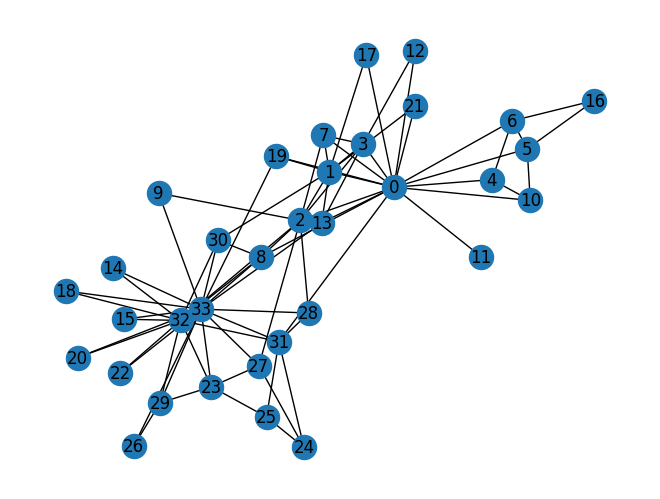

In [12]:
sel_graph = 'karate'
g = graphs[sel_graph]
nx.draw(g, with_labels=True)

In [13]:
best_results = dict()

# Apply graph based clustering

## Label Propagation

### Hyperparameter selection

2 approaches will be considered for label propagation:
1. Single run label propagation.
2. Label propagation with aggregation on multiple runs.

In [49]:
lp_trials = []

Single run experiment:

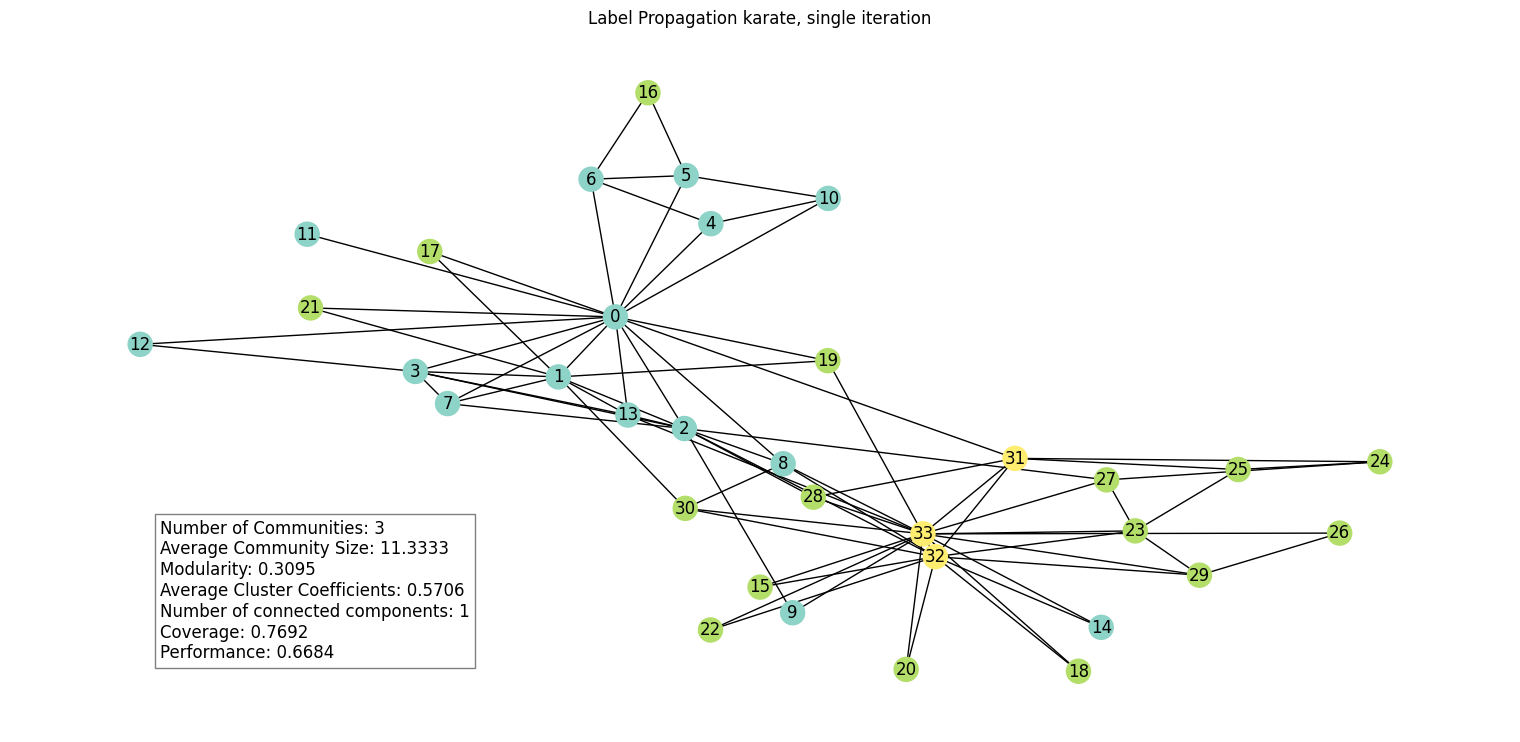

In [50]:
# single run
start = time.time()
lp_labels = label_propagation(g)
elapsed_time = time.time() - start

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
lp_trials.append({**lp_metrics, 'elapsed_time': elapsed_time, 'Iterations': 1})
plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, single iteration", metrics=lp_metrics)

For each experimental result, we print obtained partition metrics (number of communitites, average community size, modularity, coverage, performance) as well as structural info about the graph (average cluster coefficients and number of connected components).

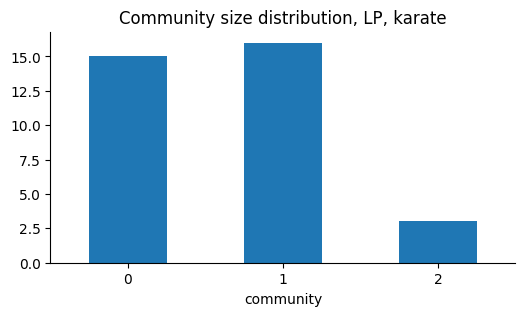

In [51]:
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

Modularity of 0.3095 is achieved by LP, with 3 communities detected. Smallest community consists of 3 people and doesn't look reasonable visually.

Experiment with 5 iterations:

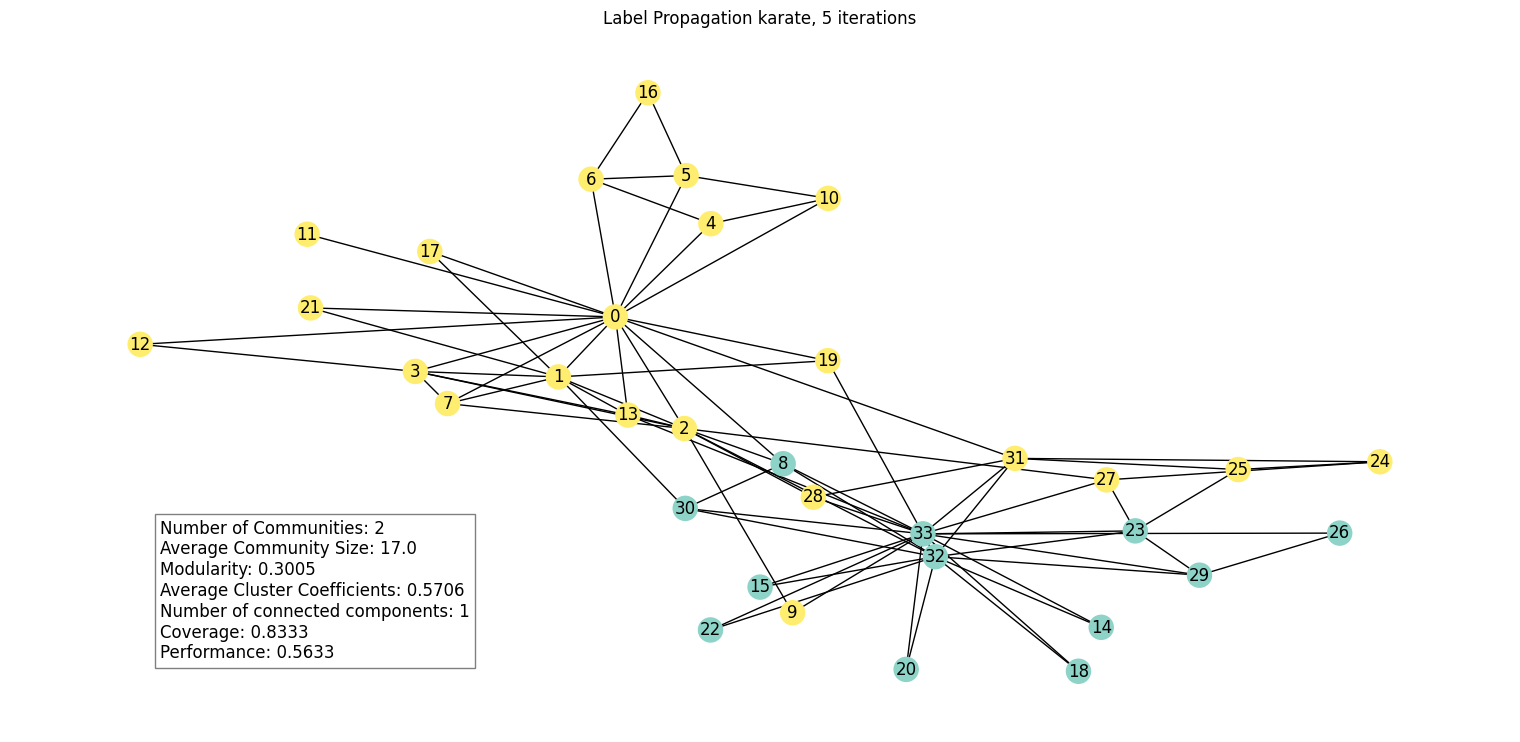

In [74]:
start = time.time()
lp_labels = label_propagation(g, aggr_runs=5)
elapsed_time = time.time() - start

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
lp_trials.append({**lp_metrics, 'elapsed_time': elapsed_time, 'Iterations': 5})
plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, 5 iterations", metrics=lp_metrics)

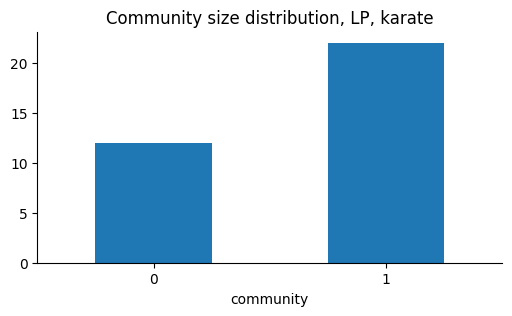

In [53]:
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

The modularity score is slightly smaller than for single run experiment, only 2 communities are detected. Some of the choices for community labels (nodes 8, 9, 28, 30) look random, but in general this looks visually better than without aggregation.

Combining together experiments with 1, 5 and 15 iterations:

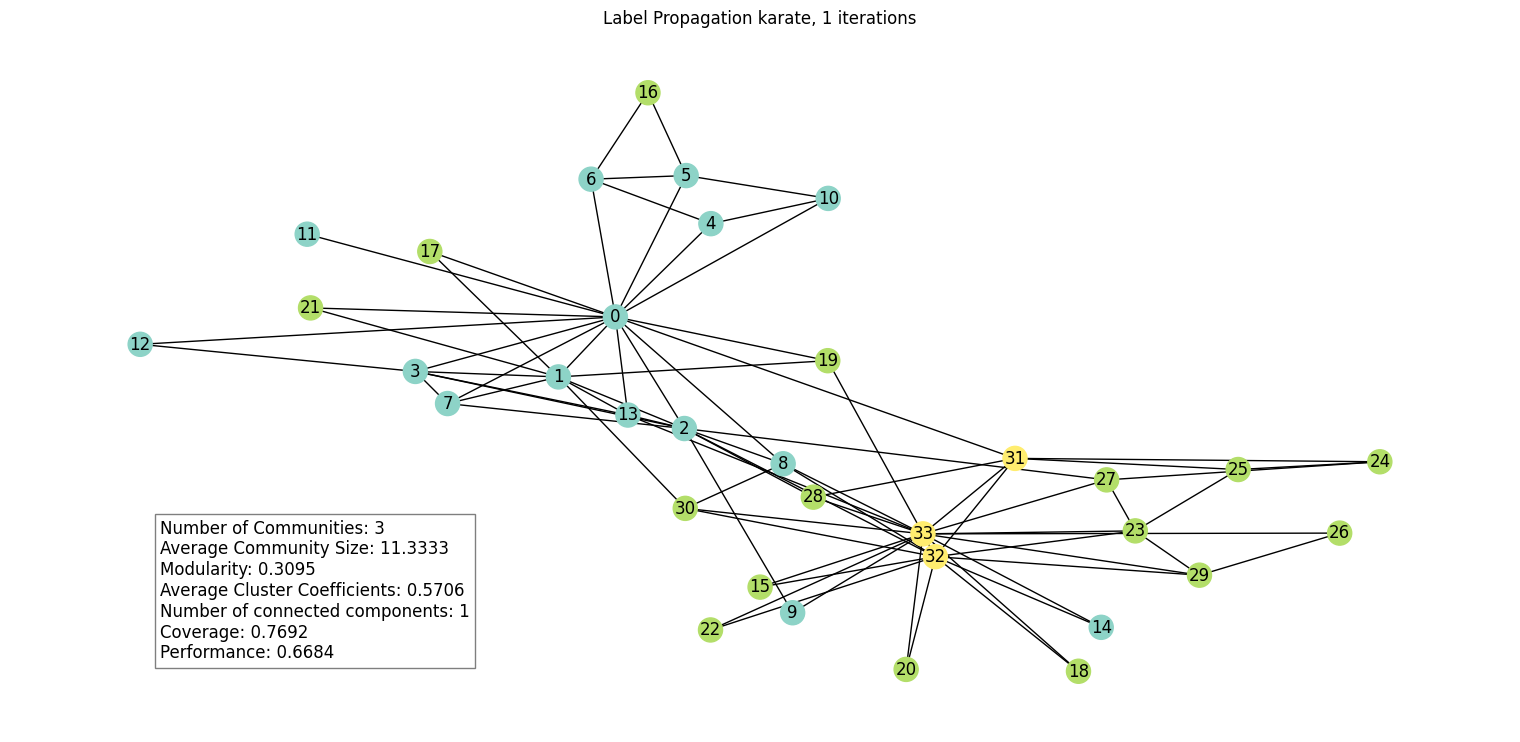

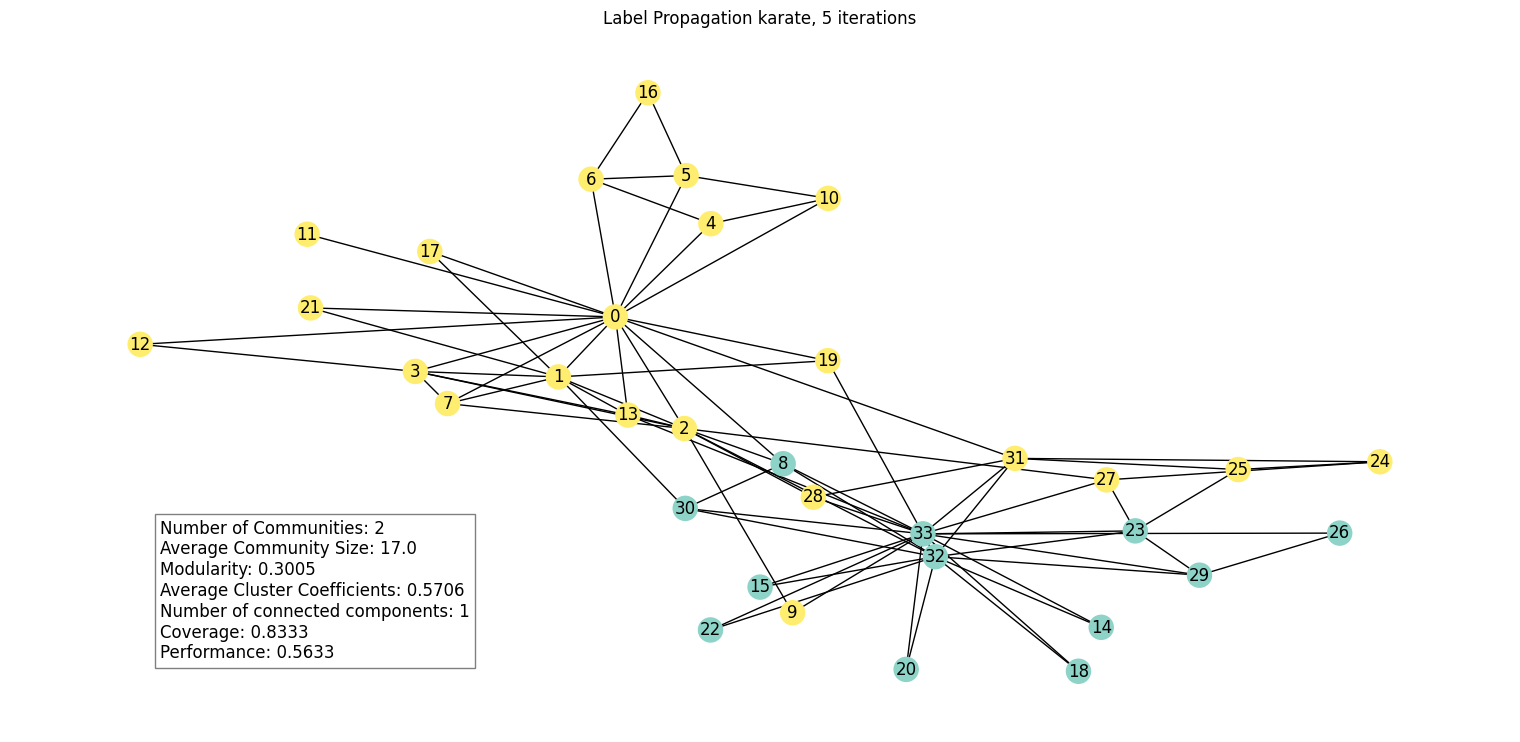

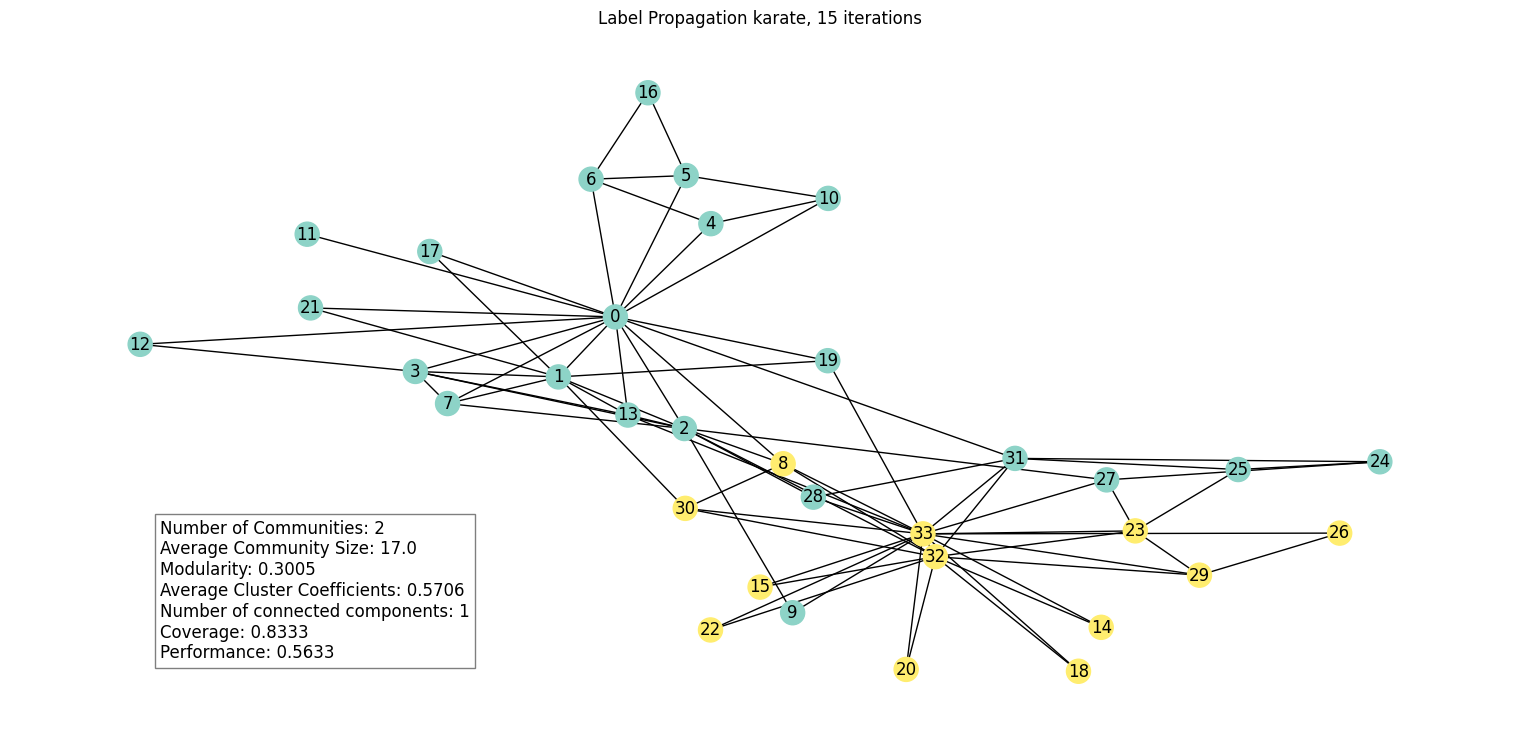

In [54]:
# based on results in paper, experiments with higher value 
# confirm authors' statement that modularity doesn't change much
for i in (1, 5, 15):
    start = time.time()
    lp_labels = label_propagation(g, aggr_runs=i)
    elapsed_time = time.time() - start

    # Calculate metrics for LP
    lp_metrics = community_metrics(g, lp_labels)
    lp_trials.append({**lp_metrics, 'elapsed_time': elapsed_time, 'Iterations': i})
    plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, {i} iterations", metrics=lp_metrics)

LP with 15 aggregate runs provides same results as with 5 runs.

In [55]:
# add best model results to final metrics
lp_df = pd.DataFrame(lp_trials)
best_results['Label Propagation'] = lp_df.loc[lp_df['Modularity'].idxmax()]

## Louvain

### Hyperparameter selection

For Louvain algorithm, `resolution` hyperparameter will be tuned.

In [56]:
lv_trials = []

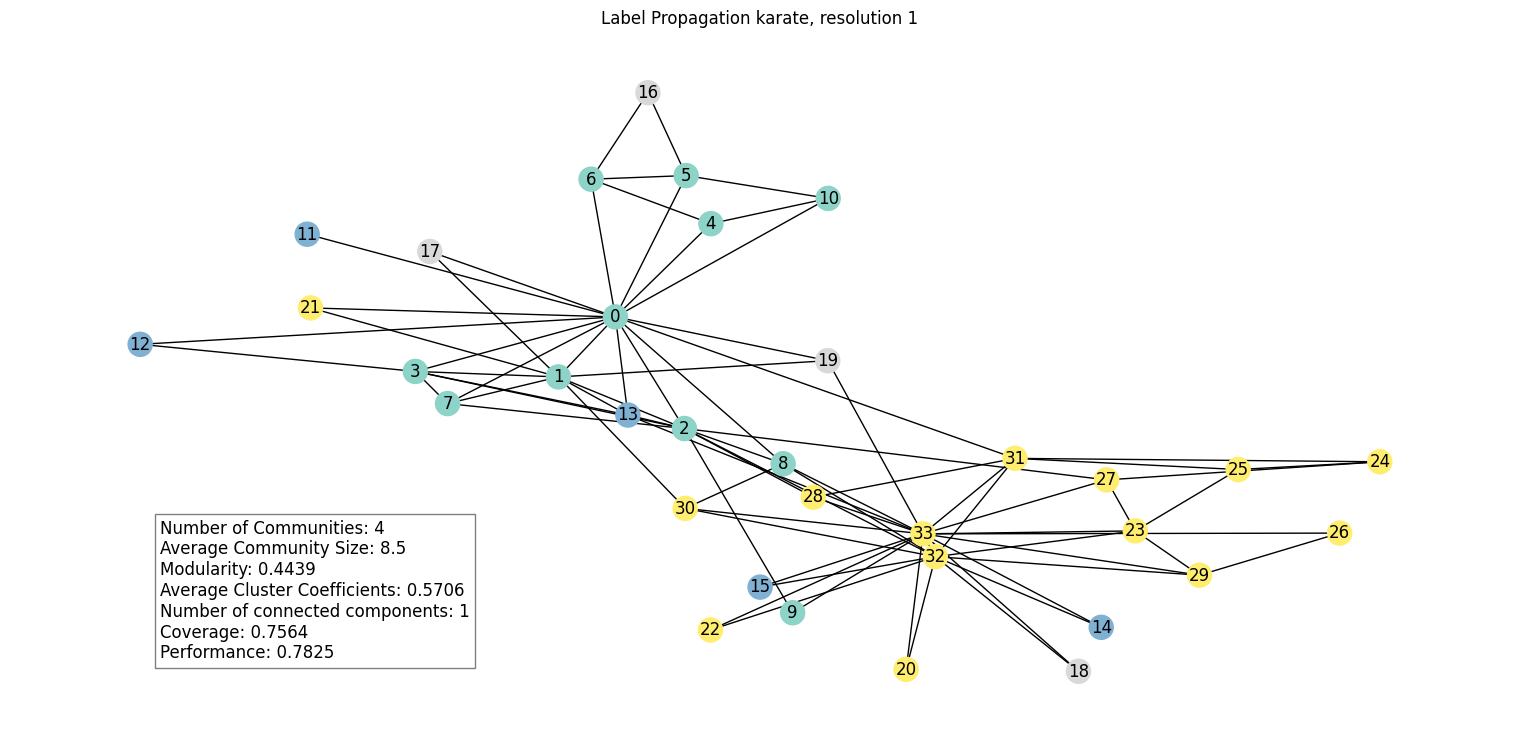

In [57]:
# default resolution
start = time.time()
lv_labels = louvain(g, resolution=1)
elapsed_time = time.time() - start

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
lv_trials.append({**lv_metrics, 'elapsed_time': elapsed_time, 'Resolution': 1})
plot_communities(g, lv_labels, title=f"Label Propagation {sel_graph}, resolution 1", metrics=lv_metrics)

4 communities detected, but visual community representation looks unreasonable see nodes 11-14, for example).

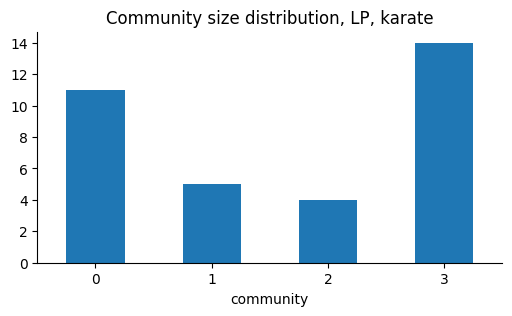

In [58]:
community_size_hist(lv_labels, title=f"Community size distribution, LP, {sel_graph}")

Running more experiments with different resolutions:

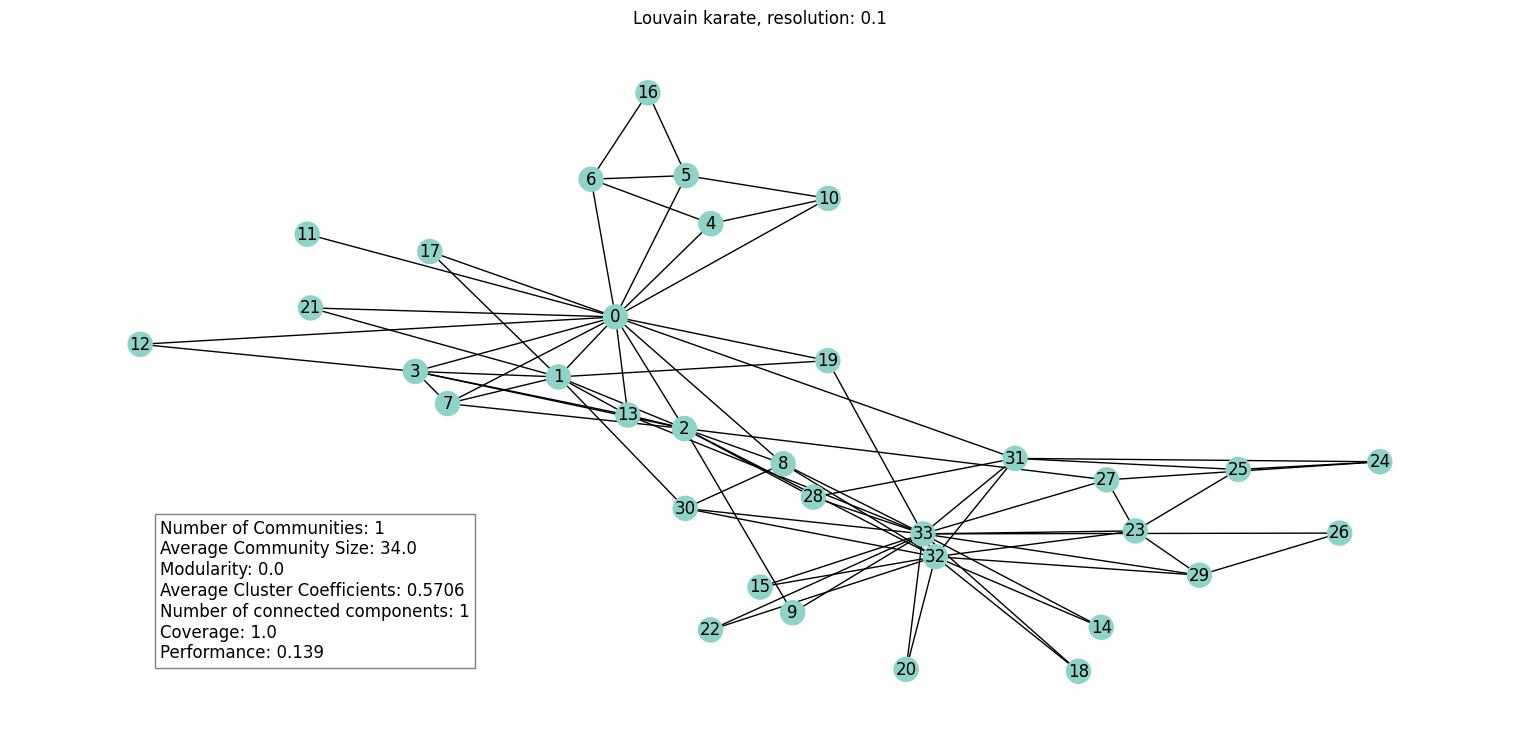

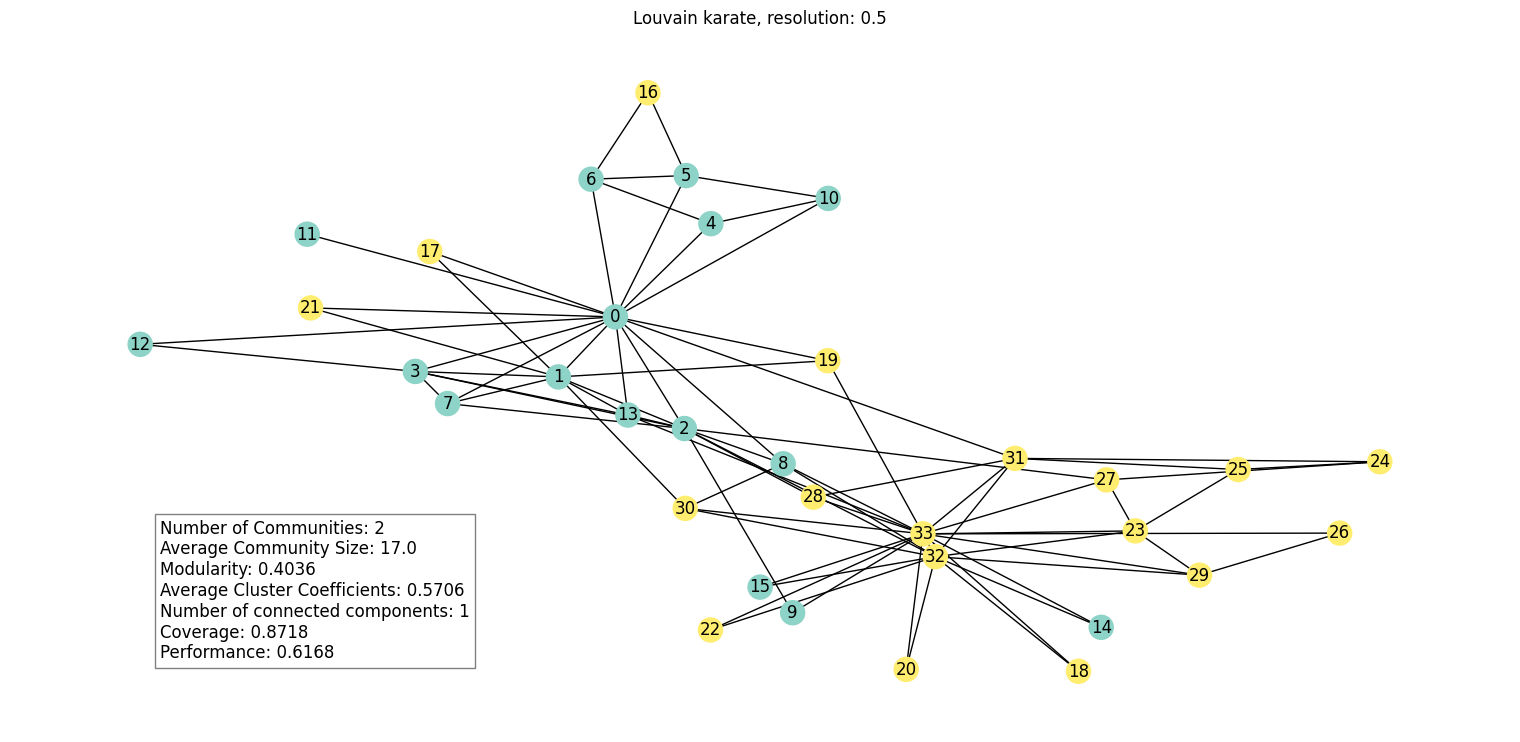

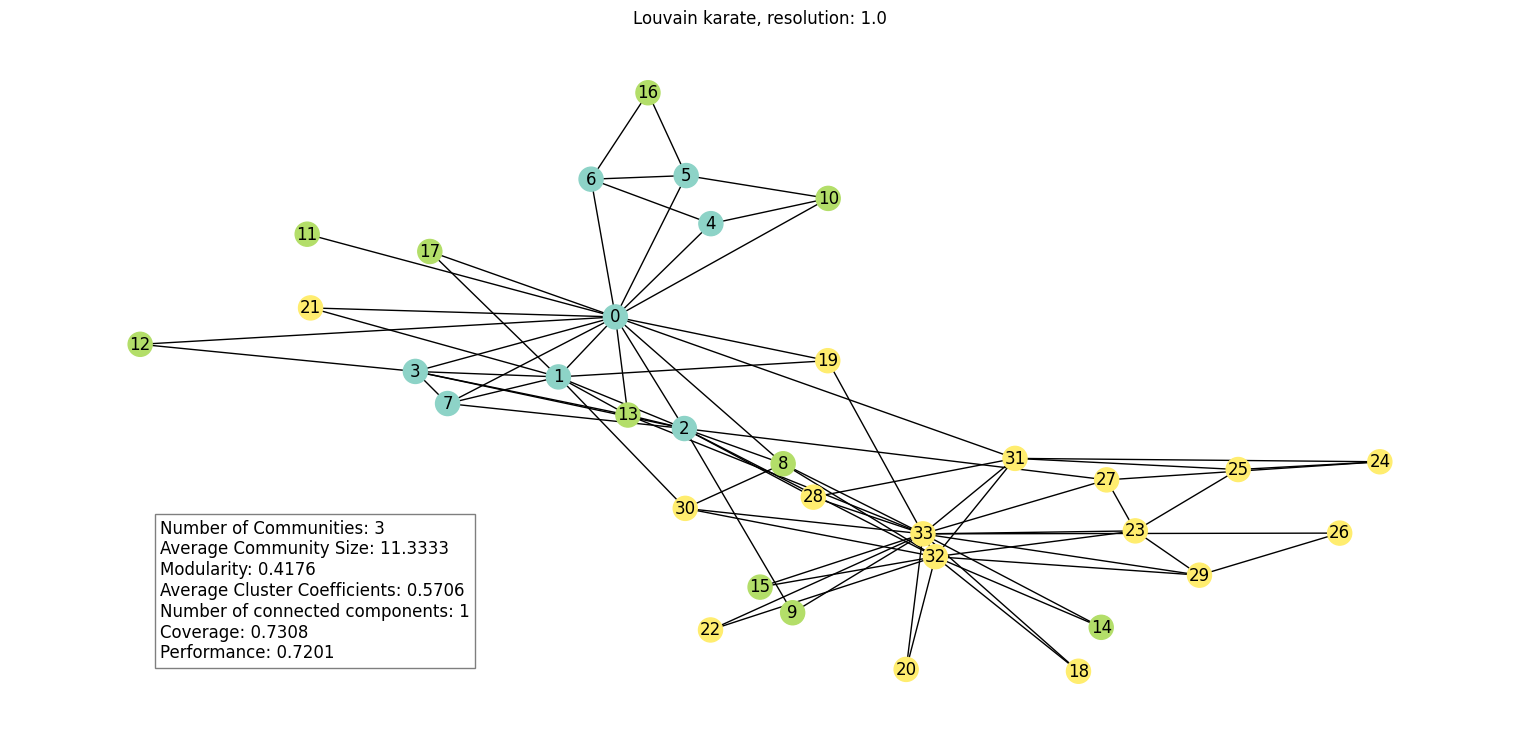

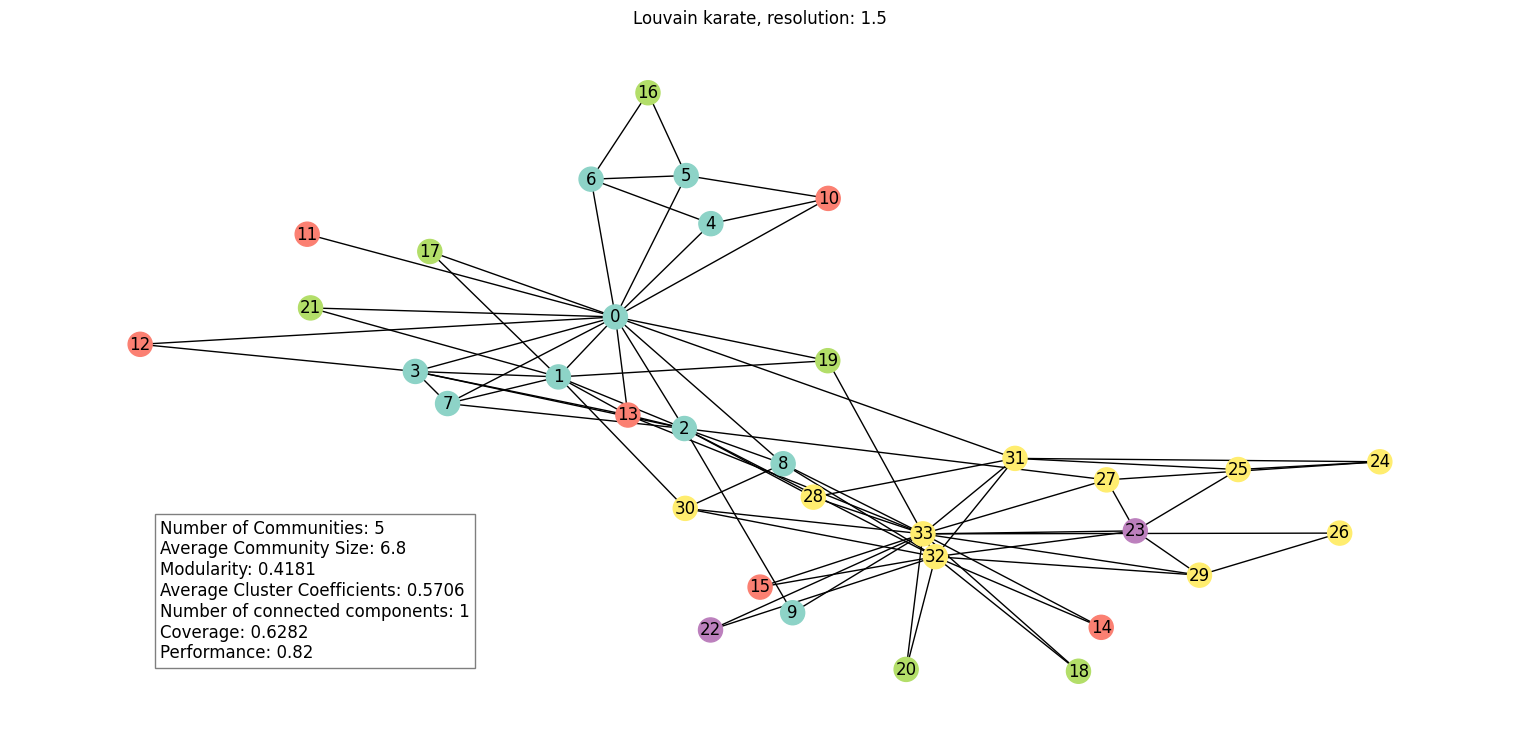

In [59]:
for i in (0.1, 0.5, 1.0, 1.5):
    start = time.time()
    lv_labels = louvain(g, resolution=i)
    elapsed_time = time.time() - start

    # Calculate metrics for Louvain
    lv_metrics = community_metrics(g, lv_labels)
    lv_trials.append({**lv_metrics, 'elapsed_time': elapsed_time, 'Resolution': i})
    plot_communities(g, lv_labels, title=f"Louvain {sel_graph}, resolution: {i}", metrics=lv_metrics)

Louvin algorithm with small resolution (0.1) detects only 1 community. Increasing resolution leads to detecting more communities, but quality is not high (see unreasonable outlier nodes 11, 16 for 0.5 resolution, for example).

In [60]:
lv_df = pd.DataFrame(lv_trials)
best_results['Louvain'] = lv_df.loc[lv_df['Modularity'].idxmax()]

## Leiden

### Hyperparameter selection

In [61]:
ld_trials = []

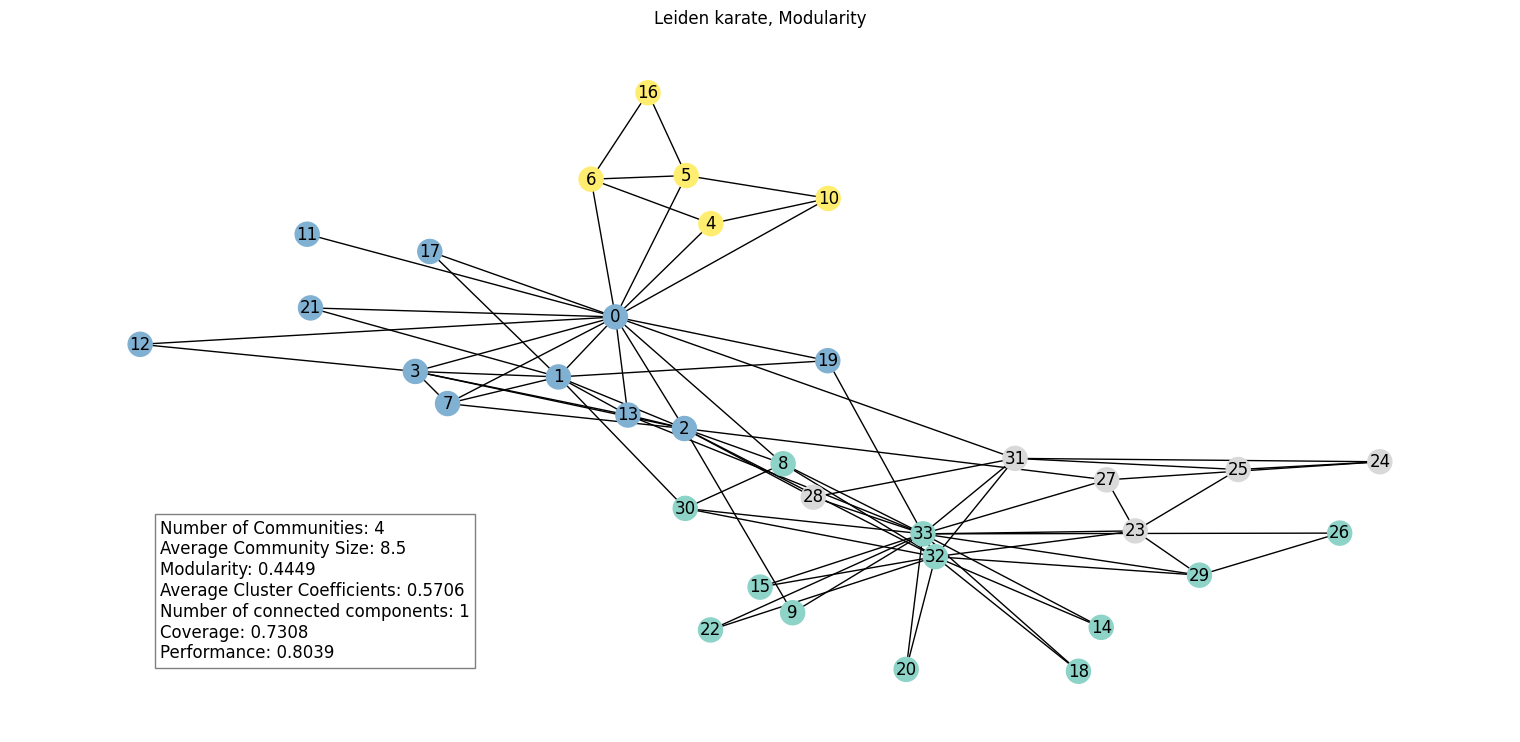

In [62]:
start = time.time()
ld_labels = leiden(g)
elapsed_time = time.time() - start

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
ld_trials.append({**ld_metrics, 'elapsed_time': elapsed_time, 'Resolution': None})
plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, Modularity", metrics=ld_metrics)

Results of Leiden algorithm look more promising visually. 4 communities are detected. Not only we obtain the highest modularity so far, but also the obtained partition looks very probable, with no unexpected outliers like with Louvin algorithm.

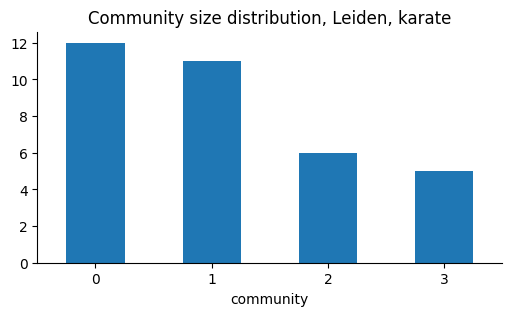

In [63]:
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

In the next experiment, 0.05 resolution is used. This triggers different partition type for the optimization. For the previous experiment, Modularity Vertex Partition algorithm was used, here the CPM vertex partition is used ([see details](https://leidenalg.readthedocs.io/en/stable/reference.html)). 

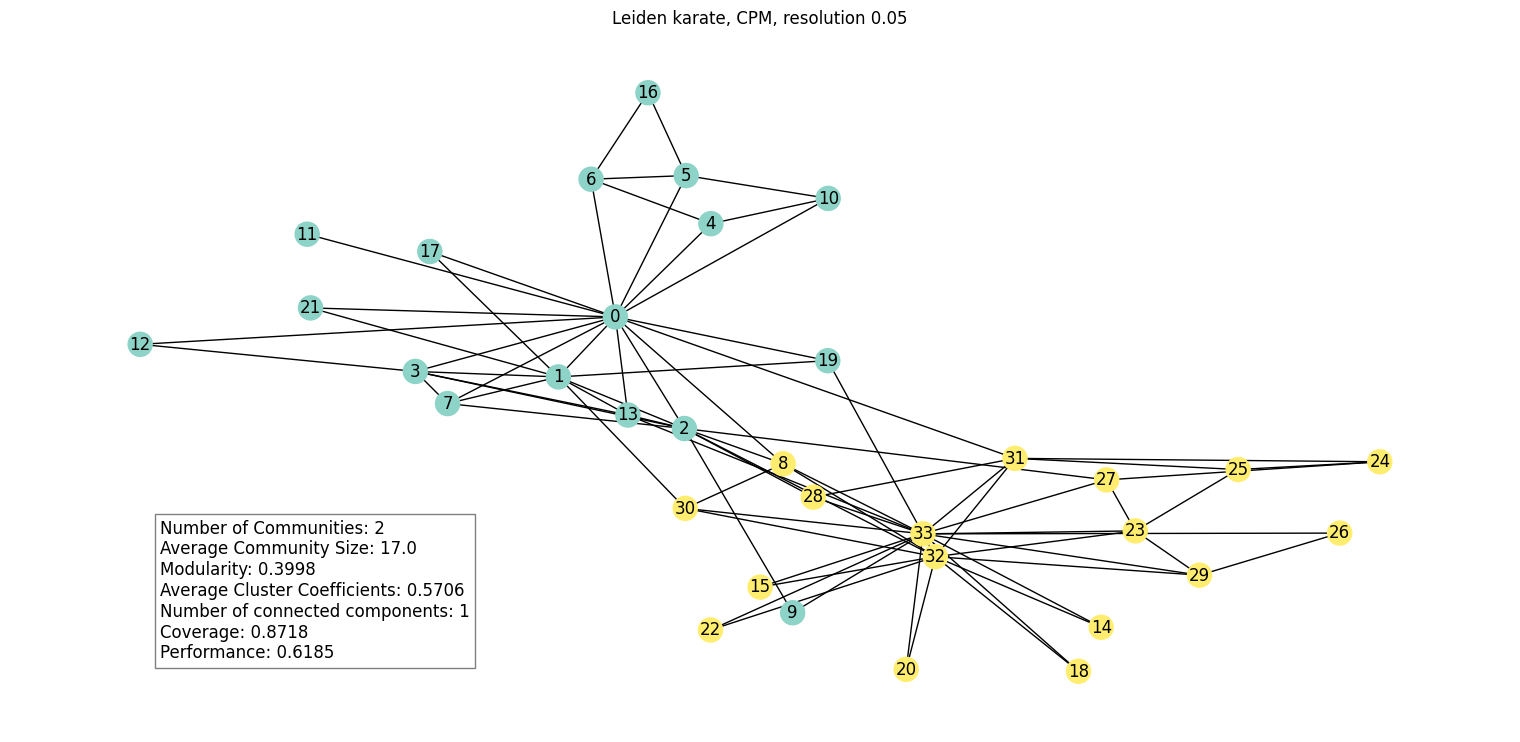

In [64]:
start = time.time()
ld_labels = leiden(g, resolution=0.05)
elapsed_time = time.time() - start

# Calculate metrics for Leiden

ld_metrics = community_metrics(g, ld_labels)
ld_trials.append({**ld_metrics, 'elapsed_time': elapsed_time, 'Resolution': 0.05})
plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, CPM, resolution 0.05", metrics=ld_metrics)

Smaller resolution leads to less communities (2) with overall still high modularity and visually reasonable partition quality.

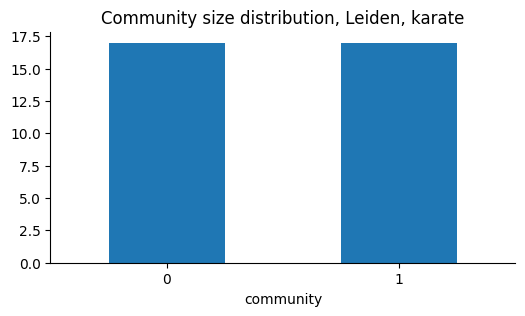

In [65]:
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

Experimenting with some more resolutions:

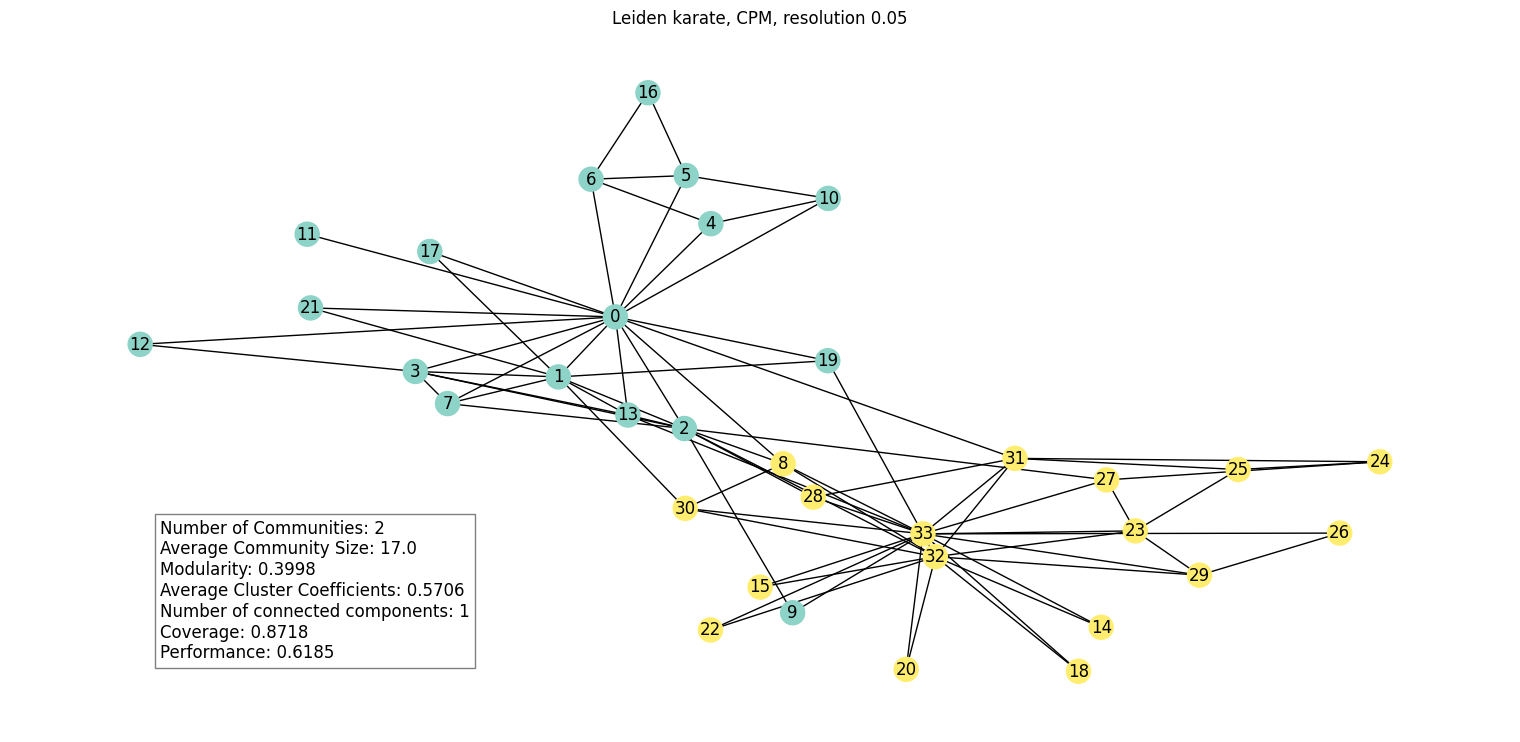

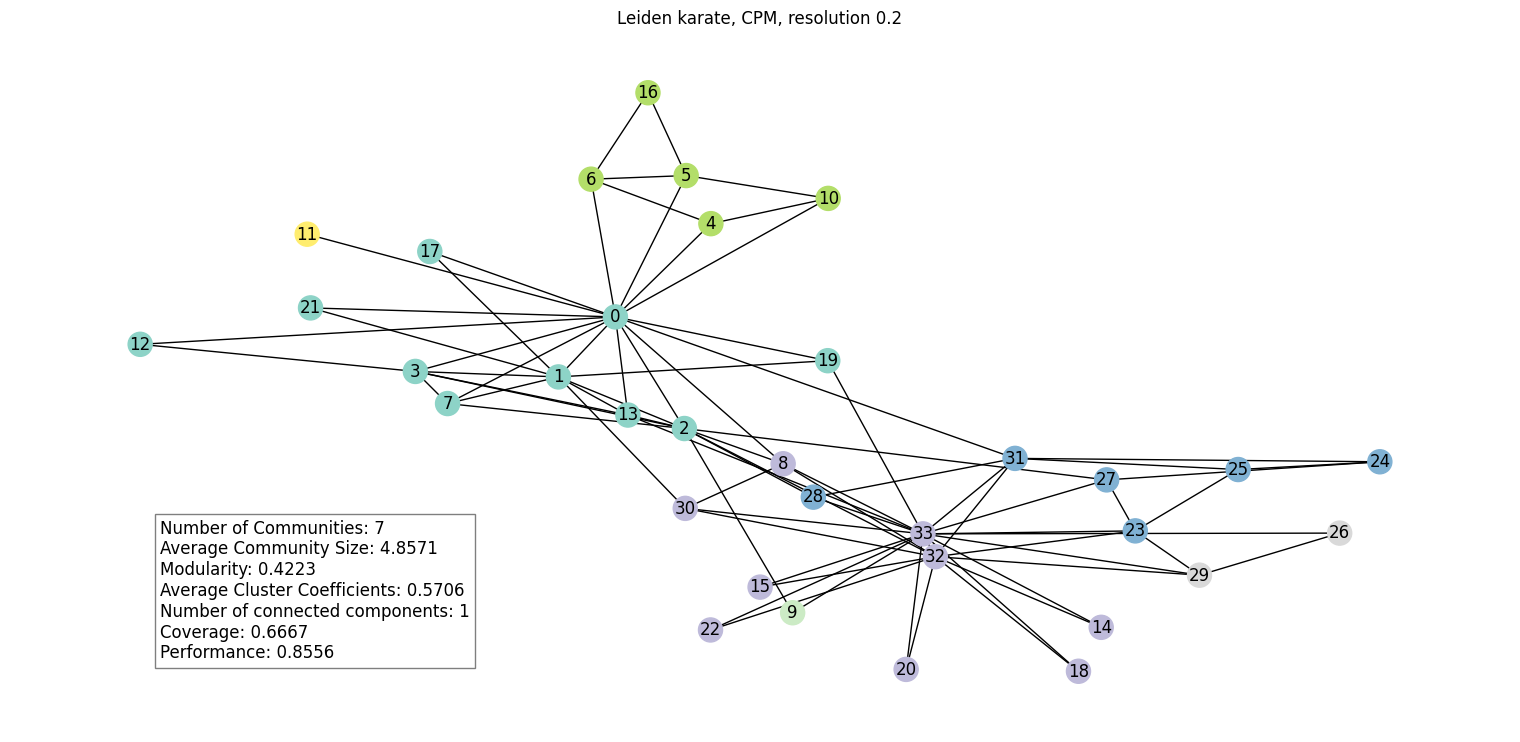

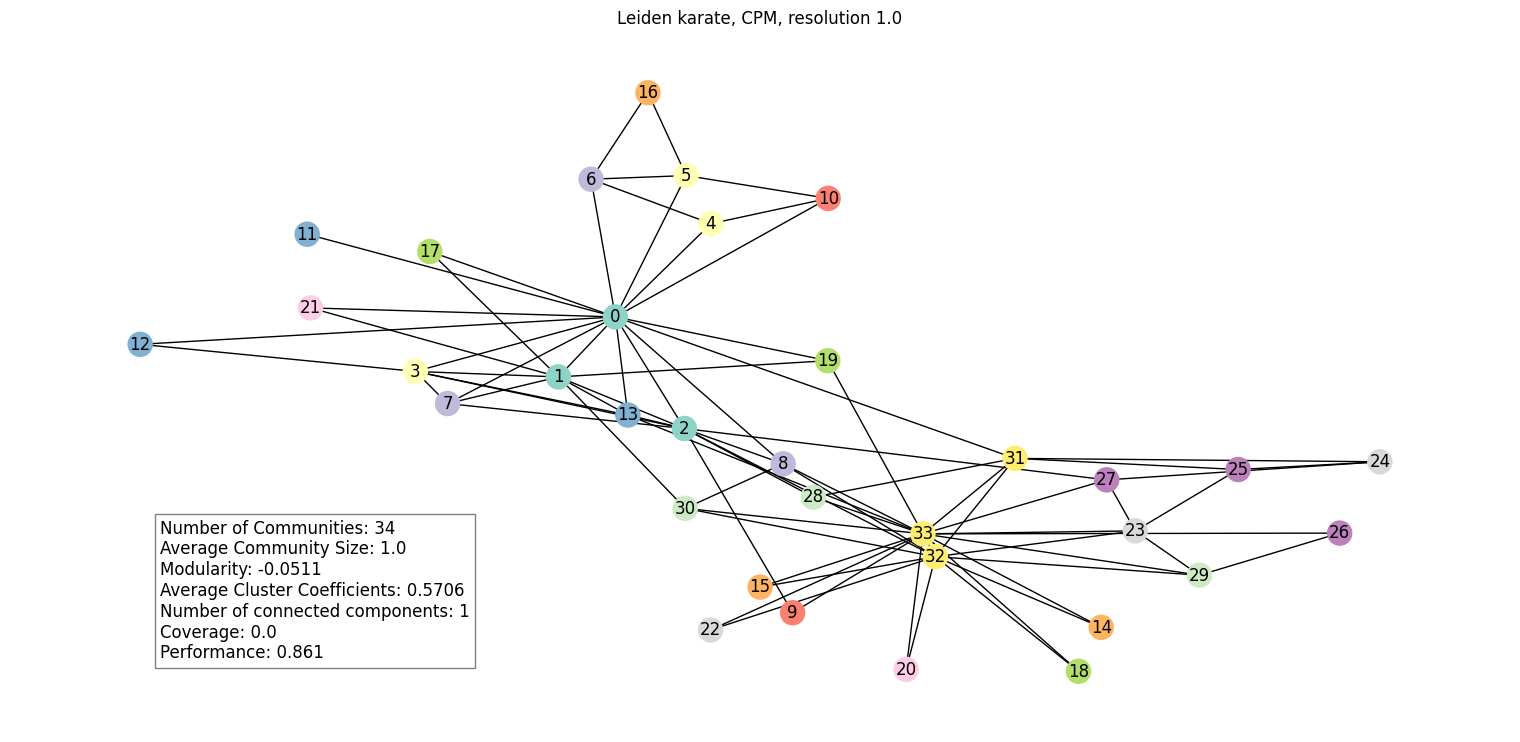

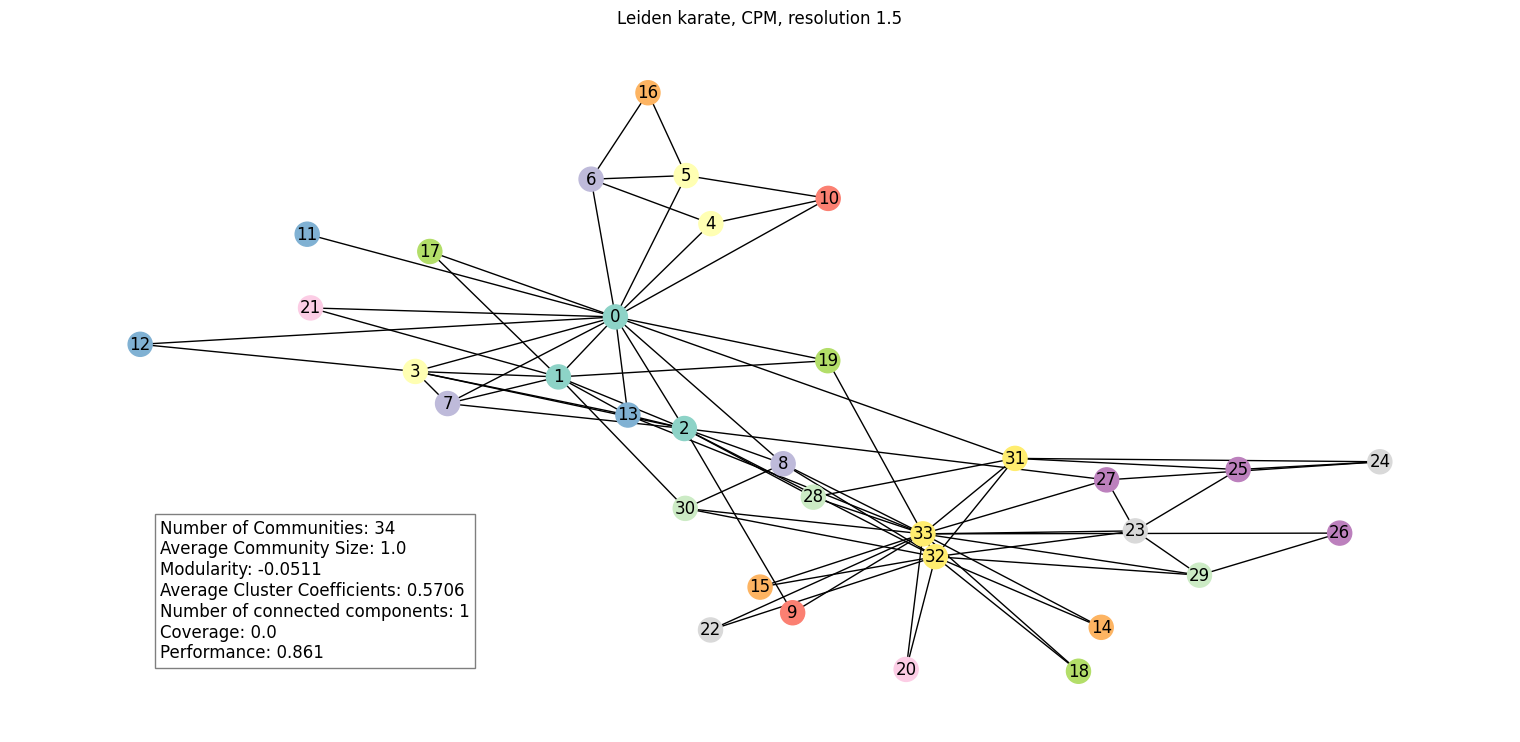

In [66]:
for i in (0.05, 0.2, 1.0, 1.5):
    start = time.time()
    ld_labels = leiden(g, resolution=i)
    elapsed_time = time.time() - start

    # Calculate metrics for Leiden
    ld_metrics = community_metrics(g, ld_labels)
    ld_trials.append({**ld_metrics, 'elapsed_time': elapsed_time, 'Resolution': i})
    plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, CPM, resolution {i}", metrics=ld_metrics)

Higher resolution values provide worse results and more clusters.

In [67]:
ld_df = pd.DataFrame(ld_trials)
best_results['Leiden'] = ld_df.loc[ld_df['Modularity'].idxmax()]

# Apply GAT Embedding

We train GAT using 3 different loss function and compare the obtained results. The loss functions are:
1. DGI (Deep Graph Infomax)
2. Embedding variance
3. Contrastive loss between connected and unconnected nodes

Best hyperparameters are selected based on the highest modularity that can be achieved by performing KMeans or Optics clustering on the obtained embeddings. The best clustering method for this purpose (in all cases turned out to be KMeans) was also implicitly selected.

In [33]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

## DGI loss

### Hyperparameter selection

In [34]:
# Select best hyperparameters
best_parameters_optuna_dgi = tune(data)

[I 2024-08-15 00:08:16,600] A new study created in memory with name: no-name-364fb185-2155-4ecd-be59-e7caf4c90d77
Best trial: 32. Best value: 0.41979: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:44<00:00,  1.13it/s]


### Model evaluation

In [35]:
# Save best hyperparameters
gat_dgi_communities = best_parameters_optuna_dgi.best_trial.user_attrs['communities']
best_method = best_parameters_optuna_dgi.best_trial.user_attrs['best_method']
best_results['GAT + DGI loss'] = best_parameters_optuna_dgi.best_trial.user_attrs['metrics']
best_results['GAT + DGI loss']['elapsed_time'] = best_parameters_optuna_dgi.best_trial.user_attrs['elapsed_time']

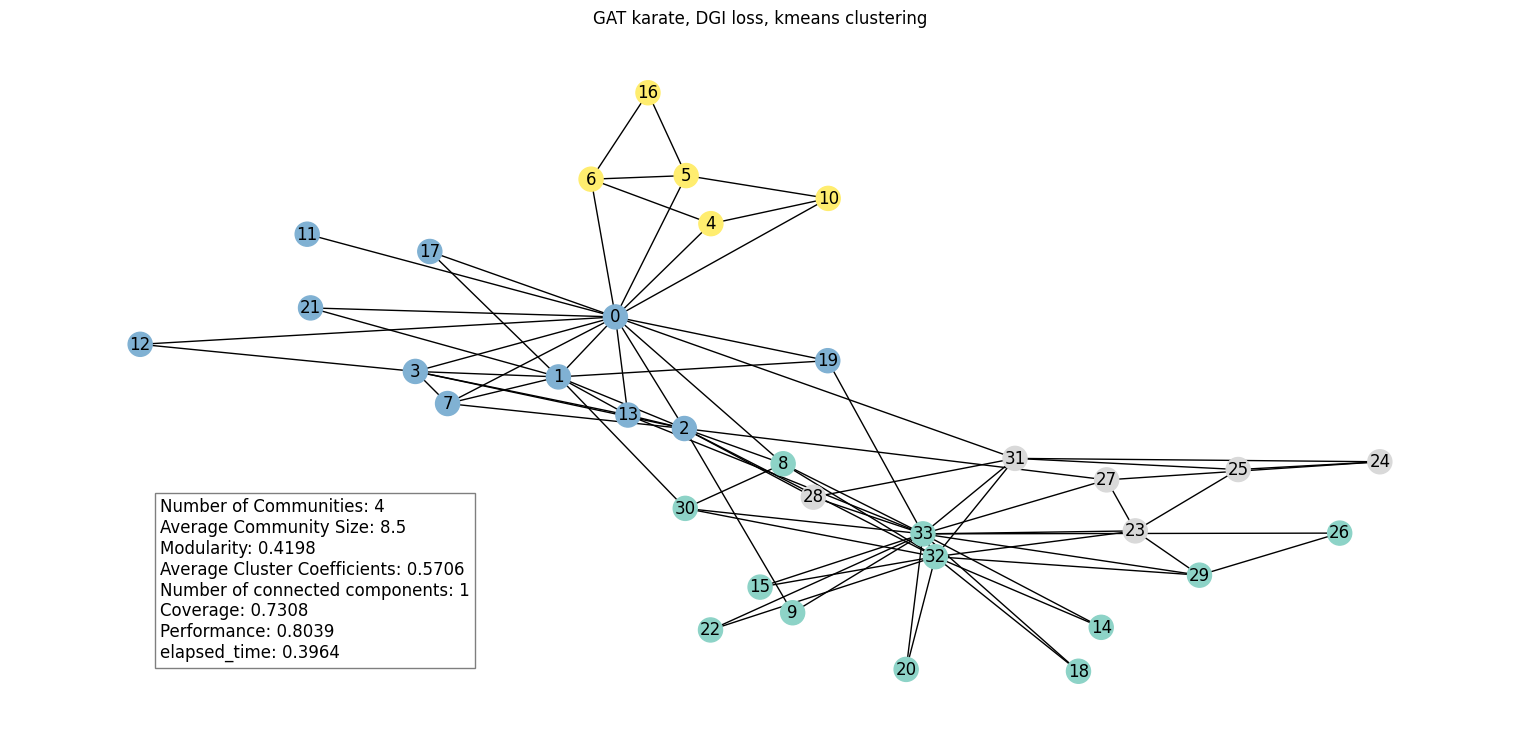

In [36]:
# Print results for the best parameters and best clustering method
plot_communities(g, gat_dgi_communities, title=f"GAT {sel_graph}, DGI loss, {best_method} clustering", metrics=best_results['GAT + DGI loss'])

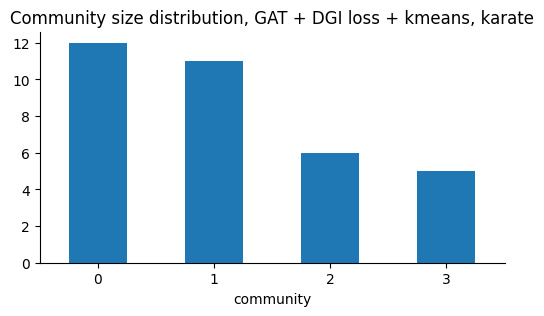

In [37]:
community_size_hist(gat_dgi_communities, title=f"Community size distribution, GAT + DGI loss + {best_method}, {sel_graph}")

4 communities detected with a rather high achieved modularity, partition looks comparable to Leiden algorithm results.

## Embedding variance loss

### Hyperparameter selection

In [38]:
best_parameters_optuna_var = tune_variance_contrastive(data, g, loss_function="variance")

Best trial: 23. Best value: 0.444904: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:17<00:00,  2.83it/s]


### Model evaluation

In [39]:
gat_var_communities = best_parameters_optuna_var.best_trial.user_attrs['communities']
best_method = best_parameters_optuna_var.best_trial.user_attrs['best_method']
best_results['GAT + variance loss'] = best_parameters_optuna_var.best_trial.user_attrs['metrics']
best_results['GAT + variance loss']['elapsed_time'] = best_parameters_optuna_var.best_trial.user_attrs['elapsed_time']

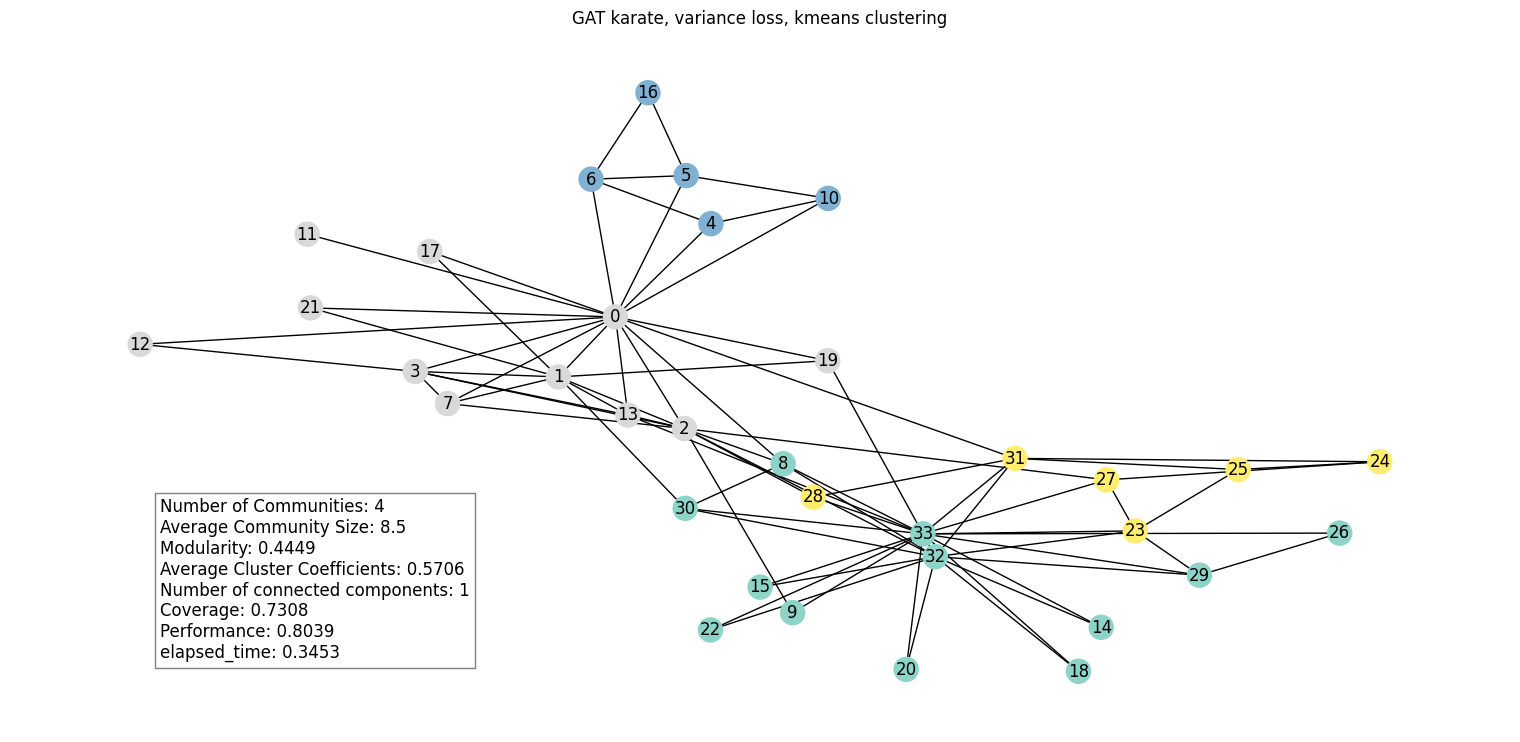

In [40]:
# get visualizations and metrics
plot_communities(g, gat_var_communities, title=f"GAT {sel_graph}, variance loss, {best_method} clustering", metrics=best_results['GAT + variance loss'])

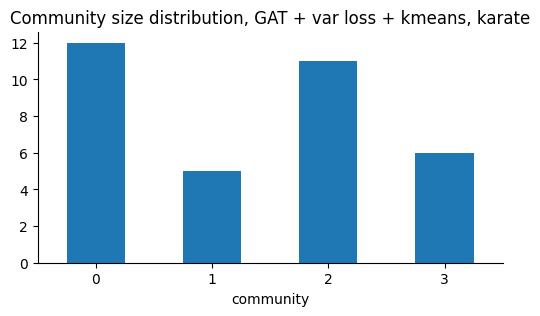

In [41]:
community_size_hist(gat_var_communities, title=f"Community size distribution, GAT + var loss + {best_method}, {sel_graph}")

Optimizing variance loss provides the same partition as Leiden algorithm in this case, metrics are identical.

## Contrastive loss

### Hyperparameter selection

In [42]:
best_parameters_optuna_con = tune_variance_contrastive(data, g, loss_function="contrastive")

Best trial: 12. Best value: 0.444904: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:38<00:00,  1.96s/it]


### Model evaluation

In [43]:
gat_con_communities = best_parameters_optuna_con.best_trial.user_attrs['communities']
best_method = best_parameters_optuna_con.best_trial.user_attrs['best_method']
best_results['GAT + contrastive loss'] = best_parameters_optuna_con.best_trial.user_attrs['metrics']
best_results['GAT + contrastive loss']['elapsed_time'] = best_parameters_optuna_con.best_trial.user_attrs['elapsed_time']

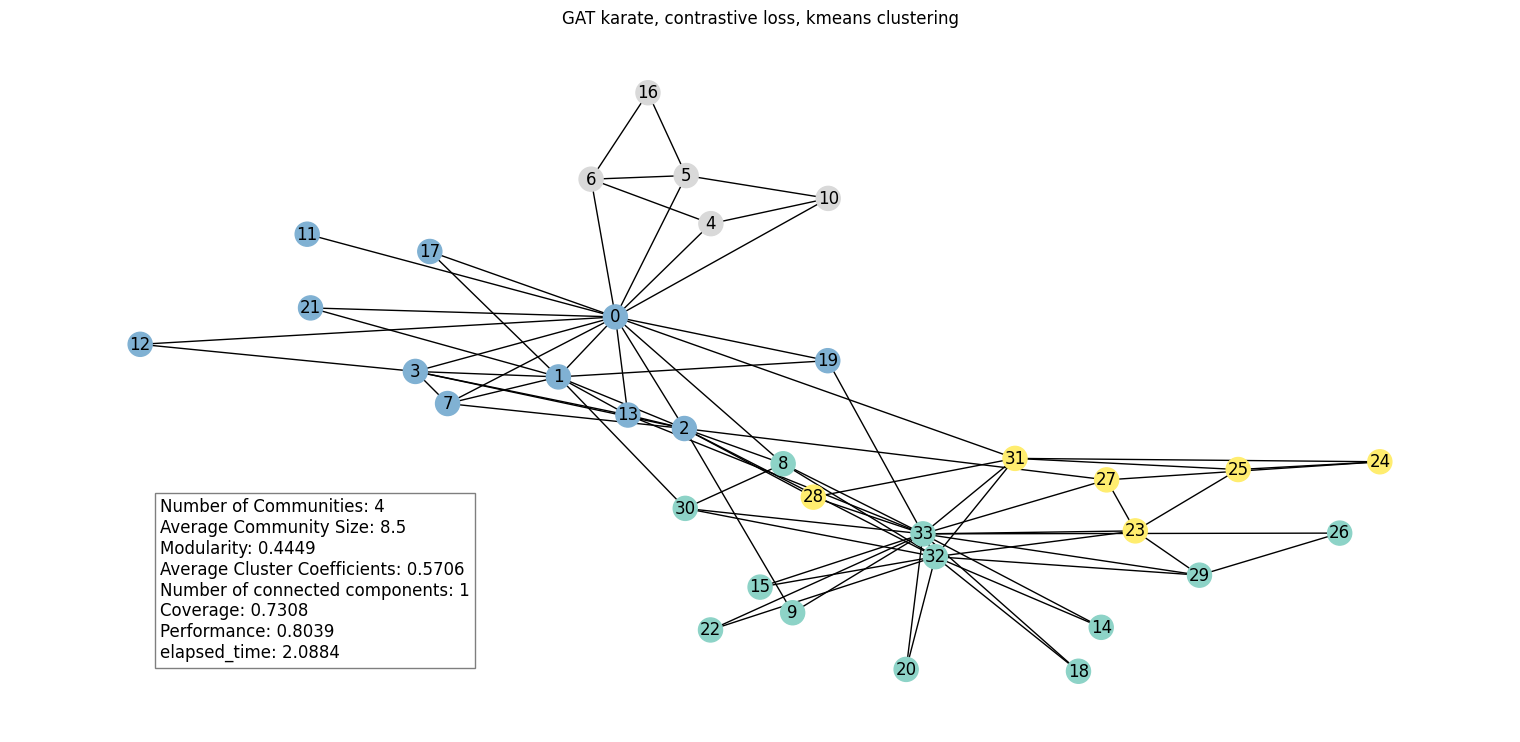

In [44]:
plot_communities(g, gat_con_communities, title=f"GAT {sel_graph}, contrastive loss, {best_method} clustering", metrics=best_results['GAT + contrastive loss'])

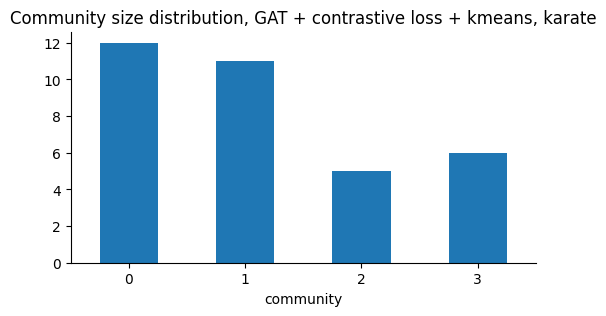

In [45]:
community_size_hist(gat_con_communities, title=f"Community size distribution, GAT + contrastive loss + {best_method}, {sel_graph}")

Optimizing contrastive loss provides the same partition as Leiden algorithm / GAT + variance loss in this case, metrics are identical.

# Final results

All the information (metrics, runtimes, optimal hyperparameters) obtained for the implemented algorithms is summarized in 3 tables.

## Metrics

In [73]:
final_metrics = pd.DataFrame(best_results).T.drop(["Average Cluster Coefficients", "Number of connected components"], axis=1)
final_metrics.style.format(precision=3).background_gradient(cmap='Blues', axis=None)

,Average Community Size,Coverage,Iterations,Modularity,Number of Communities,Performance,Resolution,elapsed_time
Label Propagation,11.333,0.769,1.000,0.309,3.000,0.668,nan,0.001
Louvain,8.500,0.756,nan,0.444,4.000,0.783,1.000,0.001
Leiden,8.500,0.731,nan,0.445,4.000,0.804,nan,0.002
GAT + DGI loss,8.500,0.731,nan,0.420,4.000,0.804,nan,0.396
GAT + variance loss,8.500,0.731,nan,0.445,4.000,0.804,nan,0.345
GAT + contrastive loss,8.500,0.731,nan,0.445,4.000,0.804,nan,2.088


All algorithms, except LP, provide very similar results in terms of metrics. "nan" for Leiden resolution means that the resolution is set to None and ModularityVertexPartition optimization is used.

## Execution times (CPU)

In [69]:
pd.DataFrame(final_metrics['elapsed_time']).T.style.format(precision=4).background_gradient(cmap='Blues', axis=None)

,Label Propagation,Louvain,Leiden,GAT + DGI loss,GAT + variance loss,GAT + contrastive loss
elapsed_time,0.0006,0.0013,0.0018,0.3964,0.3453,2.0884


LP is the fastest one, Louvain and Leiden are comparable and 1 order of magnitude slower, GAT + DGI / variance are comparable and 2 orders of magnitude slower than the latter. Optimizing contrastive loss is the slowest option.

## Optuna best hyperparameters for GAT

In [70]:
hyperparameters = pd.DataFrame({
    "GAT + DGI loss": best_parameters_optuna_dgi.best_params,
    "GAT + variance loss": best_parameters_optuna_var.best_params,
    "GAT + contrastive loss": best_parameters_optuna_con.best_params}).T
int_cols = ['hidden_channels', 'out_channels', 'heads']
hyperparameters[int_cols] = hyperparameters[int_cols].astype(int)
hyperparameters.style.format(precision=6).background_gradient(cmap='Blues', axis=None)

,hidden_channels,out_channels,heads,learning_rate,dropout,weight_decay
GAT + DGI loss,12,22,5,0.000135,0.356334,0.000127
GAT + variance loss,22,24,7,0.000170,0.466208,0.000779
GAT + contrastive loss,35,31,14,0.001023,0.208364,0.000034


DGI loss: simpler model, greater dropout.  
Contrastive loss: more complex model, less drouput, higher learning rate (1 order of magnitude). Looks like the parameters are optimized in a way to capture as much info as possible, the performance of GAT with contrastive loss can possibly be improved by increasing number of training epochs.